<a href="https://colab.research.google.com/github/kevin305-dev/hello-world/blob/main/Retrieval_Vectorstores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VectorStore

1. VectorStore는 자연어 => 숫자 처리한 후, 이들을 저장하는 벡터 저장소이다.
2. 백터 저장소는 임베딩된 데이터를 indexing하여
input으로 받아들이는 query와의 유사도를 빠르게 출력한다.
-  대표적으로 FAISS, Chroma가 존재한다.

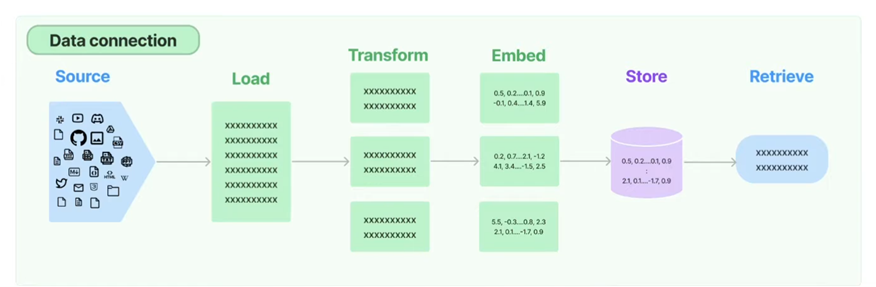

### 1. Chroma VectorStore
대표적인 오픈소스 벡터 저장소이다.

In [1]:
!pip install chromadb tiktoken transformers sentence_transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 801.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found 

- 기본적으로 VectorStore는 벡터를 일시적으로 저장한다.
  1. 변수에 저장하여 변수를 통해 검색, 문서 추가 등 한다
  2. 영구적 저장도 가능(persist directory)
- Text와 Embedding 함수를 지정하여 from_documents() 함수에 보내면, 지정된 Embedding 함수를 통해 Text를 Vector로 변환하고, 이를 임시 db로 생성한다.
- 그리고 similarity_search() 함수에 query를 지정해주면, 이를 바탕으로 유사도가 높은 vector를 찾고 이를 자연어 형태로 출력한다.
  1. 질문을 similarity_search()함수에 넣어주면
  2. 가장 유사도가 높은 vector를 찾고 이해할 수 있는 자연어로 출력

> Token을 세고 Tokenizing 처리

In [25]:
!pip install -q langchain-text-splitters

In [24]:
import tiktoken
from langchain_text_splitters import RecursiveCharacterTextSplitter

tokenizer = tiktoken.get_encoding("cl100k_base")

# token 갯수 세기 함수
def tiktoken_len(text):
  token = tokenizer.encode(text)
  return len(token)

> PDF를 불러 이 질문에 답변을 하려고 함

In [27]:
!pip install -q langchain-community langchain-chroma pypdf langchain-huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [28]:
from langchain_community.embeddings import SentenceTransformerEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders import PyPDFLoader

ImportError: cannot import name 'OTEL_LOGRECORD_ATTRIBUTE_COUNT_LIMIT' from 'opentelemetry.sdk.environment_variables' (/usr/local/lib/python3.13/dist-packages/opentelemetry/sdk/environment_variables/__init__.py)

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


> PDF 파일을 가져와서, 여러개 PAGE 별로 나누고

In [7]:
# load the document and split it into chunks
loader = PyPDFLoader("/content/drive/MyDrive/IS-200_AI_Index_2025_시사점.pdf")
pages = loader.load_and_split()

>1. Chunk 분할해서 docs에 저장
>  -  RucursiveCharacterTextSplitter 기준으로 여러 Chunk로 분할해서 docs로 저장
>2. 한국어 사전학습 Embedding 모델 정의
>  -  docs로 저장된 여러 Chunk들을 Embedding으로 바꾸기 위해
>  -  HuggingFaceEmbedding에서 한국어로 사전학습된 ko-sbert-nli 모델을 가져와
>  -  HuggingFaceEmbeddings 함수를 통해 hf에 Embedding 모델을 담음

In [9]:
# split it into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50,
    length_function = tiktoken_len
)
docs = text_splitter.split_documents(pages)

# create the open-source embedding function
from langchain_huggingface import HuggingFaceEmbeddings

model_name = "jhgan/ko-sbert-nli"
model_kwargs = {"device": "cpu"}
encode_kwargs = {"normalize_embeddings" : True}
hf = HuggingFaceEmbeddings(
    model_name = model_name,
    model_kwargs = model_kwargs,
    encode_kwargs = encode_kwargs
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  442MB            

model.safetensors: downloading bytes:           |  0.00B            

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

> 1. Chroma VectorStore에 저장
> - 과정) 문서 load => page로 분할 => Chunk로 분할 => docs 저장
> - docs에 저장된 Chunk를 =>  HuggingFaceEmbeddings 모델을 통해 => Embedding(차원/숫자)으로 바꿔서
> - Chroma VectorStore에 저장
> 2. 사용자 질의(query)와 유사성 검색(similarity_search)한 결과를 docs에 저장
> 3. 가장 유사도가 높은 내용이 무엇인지 출력(Chunk 500이하로된 내용)

In [12]:
# load it into Chroma
db = Chroma.from_documents(docs, hf)

# query it
# query = "6대 먹거리 산업은?"
query = "주목할 만한 AI 모델 수는?"

docs = db.similarity_search(query)

# print result
print(docs[0].page_content)

SPRi  이슈리포트  IS-200                                                                                            AI  Index  2025의  주요  내용  및  시사점
2
◦ (주목할 만한 AI) 2024년 Epoch.AI가 선정한 62개 주목할 만한 AI(Notable 
AI) 모델 중 미국 소재 기관들이 40개, 중국 기관들이 15개로 유럽 전체의 
3개를 크게 상회* 
* Notable AI 모델 수 : 미국(40), 중국(15), 프랑스(3), 캐나다(1), 이스라엘(1), 
사우디아라비아(1), 한국(1)2) (Epoch.ai, 2024년 모델 기준)
◦ (성능 및 비용) 산업계의 대규모 투자로 AI 모델은 증가, 성능은 향상된 반면 
비용은 급감* 
* 주목할 만한 AI 모델의 학습 연산량은 약 5개월마다 두 배로 증가, LLM(대규모 
언어 모델) 학습을 위한 데이터셋 규모는 8개월마다 두 배, 학습에 필요한 전력은 
매년 두 배로 증가하고 있는 것으로 나타남


- token 갯수도 500이하로 잘 분할된 것을 확인

In [13]:
tiktoken_len(docs[0].page_content)

473

> persist_directory()
> -  하지만, 대부분의 경우 내가 활용하고자 하는 문서를 나만의 디스크에 저장하고 필요할때마다 호출해야한다.
> -  persist() 함수를 통해벡토 저장소를 로컬로 저장하고,
> -  Chroma 객체를 선언할 때 로컬 저장소 경로를 지정하여 필요할 때 다시 불러올 수 있다.

In [14]:
# save to disk
db2 = Chroma.from_documents(docs, hf, persist_directory="./chroma_db")
docs = db2.similarity_search(query)

-  로컬저장소와 임베딩할때 사용한 옵션(hf)을 정의한 Chroma Vectorstore db3를 정의
-  사용자 질의를 db3에 넣어 유사도 검색한 결과를 docs에 담아줌

In [15]:
# load from disk
db3 = Chroma(persist_directory="./chroma_db", embedding_function=hf)
docs = db3.similarity_search(query)
print(docs[0].page_content)

SPRi  이슈리포트  IS-200                                                                                            AI  Index  2025의  주요  내용  및  시사점
2
◦ (주목할 만한 AI) 2024년 Epoch.AI가 선정한 62개 주목할 만한 AI(Notable 
AI) 모델 중 미국 소재 기관들이 40개, 중국 기관들이 15개로 유럽 전체의 
3개를 크게 상회* 
* Notable AI 모델 수 : 미국(40), 중국(15), 프랑스(3), 캐나다(1), 이스라엘(1), 
사우디아라비아(1), 한국(1)2) (Epoch.ai, 2024년 모델 기준)
◦ (성능 및 비용) 산업계의 대규모 투자로 AI 모델은 증가, 성능은 향상된 반면 
비용은 급감* 
* 주목할 만한 AI 모델의 학습 연산량은 약 5개월마다 두 배로 증가, LLM(대규모 
언어 모델) 학습을 위한 데이터셋 규모는 8개월마다 두 배, 학습에 필요한 전력은 
매년 두 배로 증가하고 있는 것으로 나타남


> similarity_search_with_score()
 -  쿼리와 유사한 문서(Chunk)를 불러올 때,
 -  유사도를 함께 제공하는 함수를 제공한다.
 -  이를 통해, 내가 얻은 유사한 문장들의 유사도를 비교할 수 있으며,
 -  특정 유사도 이상의 문서만 출력하도록 하는 등 다양한 활용이 가능함

In [16]:
# k=3..유사도가 높은 문서를 3개까지 반환(return)
docs = db3.similarity_search_with_relevance_scores(query, k=3)

print("가장 유사한 문서:\n\n {}\n\n".format(docs[0][0].page_content))
print("문서 유사도:\n {}".format(docs[0][1]))

가장 유사한 문서:

 SPRi  이슈리포트  IS-200                                                                                            AI  Index  2025의  주요  내용  및  시사점
2
◦ (주목할 만한 AI) 2024년 Epoch.AI가 선정한 62개 주목할 만한 AI(Notable 
AI) 모델 중 미국 소재 기관들이 40개, 중국 기관들이 15개로 유럽 전체의 
3개를 크게 상회* 
* Notable AI 모델 수 : 미국(40), 중국(15), 프랑스(3), 캐나다(1), 이스라엘(1), 
사우디아라비아(1), 한국(1)2) (Epoch.ai, 2024년 모델 기준)
◦ (성능 및 비용) 산업계의 대규모 투자로 AI 모델은 증가, 성능은 향상된 반면 
비용은 급감* 
* 주목할 만한 AI 모델의 학습 연산량은 약 5개월마다 두 배로 증가, LLM(대규모 
언어 모델) 학습을 위한 데이터셋 규모는 8개월마다 두 배, 학습에 필요한 전력은 
매년 두 배로 증가하고 있는 것으로 나타남


문서 유사도:
 0.45484602455183776


### 2. FAISS VectorStore
Facebook AI 유사성 검색(Faiss)은 고밀도 벡터의 효율적인 유사성 검색 및 클러스터링을 위한 라이브러리이다.
- 여기에는 모든 크기의 벡터 집합에서 검색하는 알고리즘이 포함되어 있으며,
- RAM에 맞지 않을 수 있는 벡터까지 검색할 수 있다.
- 또한 평가 및 매개변수 조정을 위한 지원 코드도 포함되어 있다.

In [15]:
!pip install faiss-cpu langchain_community langchain_huggingface pypdf # For CPU installation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 21.6 MB/s eta 0:00:00


In [22]:
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [29]:
loader = PyPDFLoader("/content/drive/MyDrive/IS-200_AI_Index_2025_시사점.pdf")
pages = loader.load_and_split()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50,
    length_function = tiktoken_len
)
docs = text_splitter.split_documents(pages)

from langchain_huggingface import HuggingFaceEmbeddings

model_name = "jhgan/ko-sbert-nli"
model_kwargs = {"device": "cpu"}
encode_kwargs = {"normalize_embeddings" : True}
ko = HuggingFaceEmbeddings(
    model_name = model_name,
    model_kwargs = model_kwargs,
    encode_kwargs = encode_kwargs
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [39]:
db = FAISS.from_documents(docs, ko)

# query = "인공지능 산업구조는 어떻게 구성되어있어?"
query = "AI 시스템의 한계를 테스트하기 위해 새롭게 도입되는 새로운 벤치마크는?"
docs = db.similarity_search(query)
print(docs[0].page_content)

소모되거나 인간대비 미흡한 성능을 보이기도 함
◦ 지금까지 AI 성능 향상 추세로 미루어볼 때, 에이전트 AI의 고성능화와 
로봇과 같은 Physical AI로의 이식이 널리 이루어 질 것으로 예상
­ 휴머노이드 보급 확대가 현실화 되는 가운데, 두뇌에 해당하는 AI의 복합 
추론에는 여전히 한계가 있어 성능 및 안전 신뢰성을 갖춘 기술 확보가 필요
­ 고성능 모델은 Agentic AI, Physical AI의 기반이 될 것이므로, 
국내에서도 안전성을 갖춘 고성능 AI 엔진 확보를 위한 지원 확대가 시급함
(a) 바리스타 로봇 (b) 자동차 조립 로봇
※ 자료: Standford HAI, AI Index Report 2025, Figure AI(2025)
[그림]  휴머노이드 사례  (Figure AI社의  Figure 02모델)


-  similarity_search_with_score : 점수가 낮을수록 거리가 가깝다(=유사도가 높다)
-  vector간의 거리가 가까울수록 낮은 점수(=query와 유사도가 높다)

In [43]:
docs_and_scores = db.similarity_search_with_score(query)
docs_and_scores
# print(docs_and_scores[0][0].page_content)
# print(docs_and_scores)

[(Document(id='21302adc-1a4d-4867-8997-80c6a973e070', metadata={'producer': 'Samsung Electronics', 'creator': 'Samsung Electronics', 'creationdate': '', 'moddate': '2026-09-17T16:34:06+09:00', 'source': '/content/drive/MyDrive/IS-200_AI_Index_2025_시사점.pdf', 'total_pages': 27, 'page': 21, 'page_label': '22'}, page_content='소모되거나 인간대비 미흡한 성능을 보이기도 함\n◦ 지금까지 AI 성능 향상 추세로 미루어볼 때, 에이전트 AI의 고성능화와 \n로봇과 같은 Physical AI로의 이식이 널리 이루어 질 것으로 예상\n\xad 휴머노이드 보급 확대가 현실화 되는 가운데, 두뇌에 해당하는 AI의 복합 \n추론에는 여전히 한계가 있어 성능 및 안전 신뢰성을 갖춘 기술 확보가 필요\n\xad 고성능 모델은 Agentic AI, Physical AI의 기반이 될 것이므로, \n국내에서도 안전성을 갖춘 고성능 AI 엔진 확보를 위한 지원 확대가 시급함\n(a) 바리스타 로봇 (b) 자동차 조립 로봇\n※ 자료: Standford HAI, AI Index Report 2025, Figure AI(2025)\n[그림]\x00 휴머노이드\x00사례\x00 (Figure\x00AI社의\x00 Figure\x0002모델)'),
  np.float32(0.89089036)),
 (Document(id='7f8fc0a7-3028-408a-93cb-5f4c916d041d', metadata={'producer': 'Samsung Electronics', 'creator': 'Samsung Electronics', 'creationdate': '', 'moddate': '2026-09-17T16:34:06+09:00', '

-  Local에 저장

In [42]:
db.save_local("faiss_index")

- Local에 저장된 vectorstore(db)를 불러옴
- "faiss_index" 이름으로 저장한 vector embedding index값들을 new_db로 가져옴
> 실제로 LLM이 이 CONTEXT를 가지고 답변할때 근거(페이지 번호 등)를 가지고 답변할 수 있으므로, *** VectorStore*** 가 중요한 역할을 한다.

In [49]:
import os
from langchain_community.vectorstores import FAISS

# Chunk된 pages를 HuggingFaceEmbeddings 모델 ko로 임베딩된 vector값을 vectorstore FAISS인 new_db에 저장
# 'allow_dangerous_deserialization=True'를 추가하여 pickle 파일 로딩을 허용합니다.
new_db = FAISS.load_local("faiss_index", ko, allow_dangerous_deserialization=True)

query = "AI 시스템의 한계를 테스트하기 위해 새롭게 도입되는 새로운 벤치마크는?"
docs = new_db.similarity_search_with_relevance_scores(query, k=3)

print("질문: {} \n".format(query))
for i in range(len(docs)):
  print("{0}번째 유사 문서 유사도 \n{1}".format(i+1,round(docs[i][1],2)))
  print("-"*100)
  print(docs[i][0].page_content)
  print("\n")
  # Check if metadata exists before trying to access it
  if docs[i][0].metadata:
    print(docs[i][0].metadata)
  else:
    print("No metadata available")
  print("-"*100)

질문: AI 시스템의 한계를 테스트하기 위해 새롭게 도입되는 새로운 벤치마크는? 

1번째 유사 문서 유사도 
0.3700000047683716
----------------------------------------------------------------------------------------------------
소모되거나 인간대비 미흡한 성능을 보이기도 함
◦ 지금까지 AI 성능 향상 추세로 미루어볼 때, 에이전트 AI의 고성능화와 
로봇과 같은 Physical AI로의 이식이 널리 이루어 질 것으로 예상
­ 휴머노이드 보급 확대가 현실화 되는 가운데, 두뇌에 해당하는 AI의 복합 
추론에는 여전히 한계가 있어 성능 및 안전 신뢰성을 갖춘 기술 확보가 필요
­ 고성능 모델은 Agentic AI, Physical AI의 기반이 될 것이므로, 
국내에서도 안전성을 갖춘 고성능 AI 엔진 확보를 위한 지원 확대가 시급함
(a) 바리스타 로봇 (b) 자동차 조립 로봇
※ 자료: Standford HAI, AI Index Report 2025, Figure AI(2025)
[그림]  휴머노이드 사례  (Figure AI社의  Figure 02모델)


{'producer': 'Samsung Electronics', 'creator': 'Samsung Electronics', 'creationdate': '', 'moddate': '2026-09-17T16:34:06+09:00', 'source': '/content/drive/MyDrive/IS-200_AI_Index_2025_시사점.pdf', 'total_pages': 27, 'page': 21, 'page_label': '22'}
----------------------------------------------------------------------------------------------------
2번째 유사 문서 유사도 
0.3400000035762787
----------------

> SimilaritySearch vs Max_Marginal_Relevance_Search
-  SimilaritySearch : 유사도 기준 높은 유사도 문서를 변환
-  Max_Marginal_Relevance_Search : 가장 높은 유사도, 뽑힌 문서들 중 다양성을 추구함

In [56]:
query = "AI 시스템의 한계를 테스트하기 위해 새롭게 도입되는 새로운 벤치마크는?"
docs = new_db.max_marginal_relevance_search(query, k=3, fetch_k = 10, lambda_mult=0.3)

print("질문: {} \n".format(query))
for i in range(len(docs)):
  print("{}번째 유사 문서".format(i+1))
  print("-"*100)
  print(docs[i].page_content)
  print("\n")
  # Check if metadata exists before trying to access it
  if docs[i].metadata:
    print(docs[i].metadata)
  else:
    print("No metadata available")
  print("-"*100)

질문: AI 시스템의 한계를 테스트하기 위해 새롭게 도입되는 새로운 벤치마크는? 

1번째 유사 문서
----------------------------------------------------------------------------------------------------
소모되거나 인간대비 미흡한 성능을 보이기도 함
◦ 지금까지 AI 성능 향상 추세로 미루어볼 때, 에이전트 AI의 고성능화와 
로봇과 같은 Physical AI로의 이식이 널리 이루어 질 것으로 예상
­ 휴머노이드 보급 확대가 현실화 되는 가운데, 두뇌에 해당하는 AI의 복합 
추론에는 여전히 한계가 있어 성능 및 안전 신뢰성을 갖춘 기술 확보가 필요
­ 고성능 모델은 Agentic AI, Physical AI의 기반이 될 것이므로, 
국내에서도 안전성을 갖춘 고성능 AI 엔진 확보를 위한 지원 확대가 시급함
(a) 바리스타 로봇 (b) 자동차 조립 로봇
※ 자료: Standford HAI, AI Index Report 2025, Figure AI(2025)
[그림]  휴머노이드 사례  (Figure AI社의  Figure 02모델)


{'producer': 'Samsung Electronics', 'creator': 'Samsung Electronics', 'creationdate': '', 'moddate': '2026-09-17T16:34:06+09:00', 'source': '/content/drive/MyDrive/IS-200_AI_Index_2025_시사점.pdf', 'total_pages': 27, 'page': 21, 'page_label': '22'}
----------------------------------------------------------------------------------------------------
2번째 유사 문서
----------------------------------------------------------------